# Sales Performance Analysis

## Setup

In [66]:
import os, warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType, IntegerType

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.stat import Correlation

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120})

print("imports ok")

imports ok


In [67]:
# 2 workers, 1 driver — each gets 2 GB
spark = (
    SparkSession.builder
    .appName("SalesAnalysis")
    .master("local[3]")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.executor.cores", "1")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

sc = spark.sparkContext
print(f"Spark {spark.version}")
print(f"Driver memory : {sc._conf.get('spark.driver.memory')}")
print(f"Executor memory: {sc._conf.get('spark.executor.memory')}")
print(f"Cores : {sc.defaultParallelism}")

Spark 4.1.1
Driver memory : 2g
Executor memory: 2g
Cores : 3


## Load Data

In [68]:
BASE = "/home/saag/Documents/BigDataCW/cleaned_dataset"

def read_csv(name):
    """Read partitioned CSV directory."""
    return spark.read.csv(os.path.join(BASE, name), header=True, inferSchema=True)

orders      = read_csv("orders_cleaned.csv")
order_items = read_csv("order_items_cleaned.csv")
products    = read_csv("products_cleaned.csv")
customers   = read_csv("customers_cleaned.csv")
date_dim    = read_csv("date_dim_cleaned.csv")

for name, df in [("orders", orders), ("order_items", order_items),
                 ("products", products), ("customers", customers), ("date_dim", date_dim)]:
    print(f"{name:15s}  rows={df.count():>7,}  cols={len(df.columns)}")

orders           rows=400,000  cols=9
order_items      rows=919,204  cols=6
products         rows=  5,000  cols=8
customers        rows=121,200  cols=9
date_dim         rows=  2,557  cols=10


In [69]:
# join items to orders and products
fact = (
    order_items
    .join(orders,   on="order_id",   how="inner")
    .join(products, on="product_id", how="inner")
    .withColumn("revenue", F.col("line_total"))
    .withColumn("profit",  F.col("line_total") * (1 - F.col("discount_pct")) * 0.30)
    .withColumn("order_year",  F.year("order_date"))
    .withColumn("order_month", F.month("order_date"))
)

# only delivered orders count as confirmed revenue
delivered = fact.filter(F.col("order_status") == "Delivered")

print(f"all rows      : {fact.count():,}")
print(f"delivered rows: {delivered.count():,}")

all rows      : 918,954


delivered rows: 552,629


## KPI Overview

In [70]:
kpi = delivered.agg(
    F.round(F.sum("revenue"), 2).alias("total_revenue"),
    F.round(F.sum("profit"),  2).alias("total_profit"),
    F.countDistinct("order_id").alias("total_orders"),
    F.round(F.avg("revenue"), 2).alias("avg_order_value"),
).collect()[0]

total_revenue   = kpi["total_revenue"]
total_profit    = kpi["total_profit"]
total_orders    = kpi["total_orders"]
avg_order_value = kpi["avg_order_value"]

print(f"Revenue   : NPR {total_revenue:>15,.2f}")
print(f"Profit    : NPR {total_profit:>15,.2f}")
print(f"Orders    :     {total_orders:>15,}")
print(f"Avg Order : NPR {avg_order_value:>15,.2f}")

Revenue   : NPR 12,411,411,059.32
Profit    : NPR 3,281,674,597.07
Orders    :             240,352
Avg Order : NPR       22,458.85


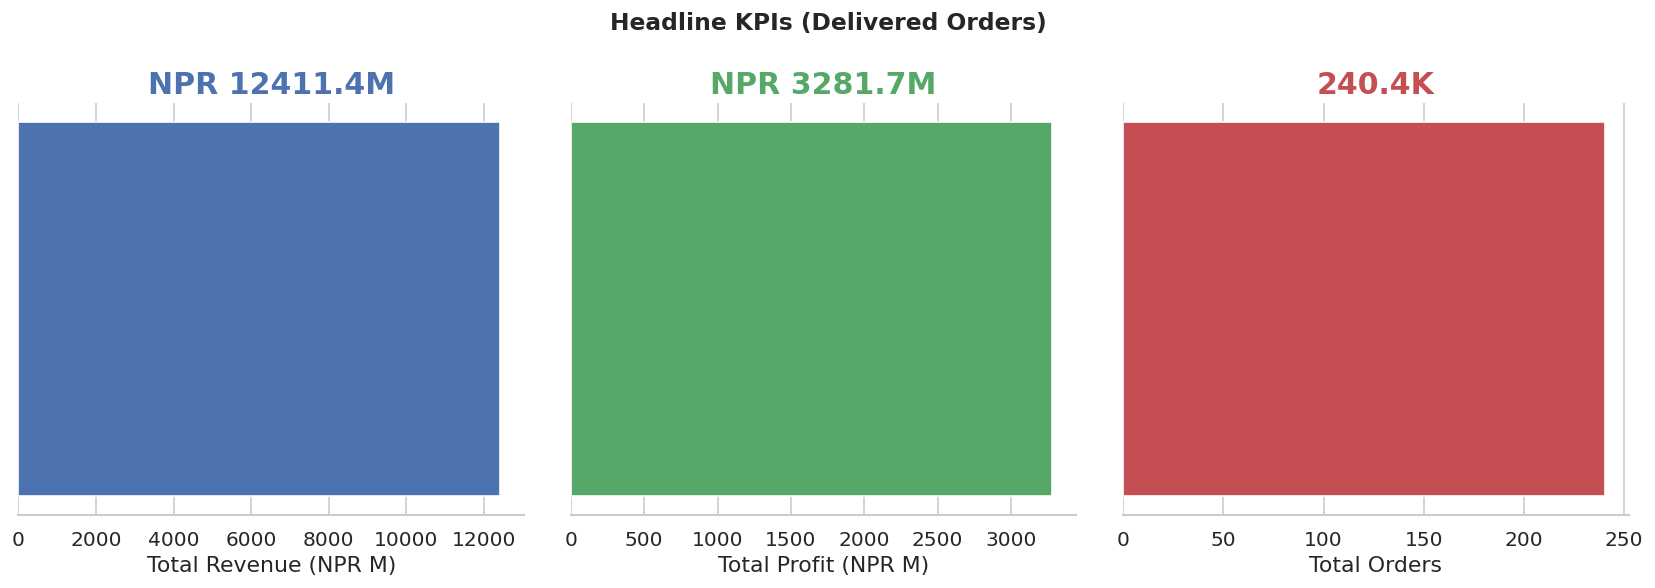

In [71]:
# KPI dashboard — 3 horizontal bars for revenue, profit, orders
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Headline KPIs (Delivered Orders)", fontsize=14, fontweight="bold")

kpi_data = [
    ("Total Revenue (NPR M)", total_revenue / 1e6, "NPR {:.1f}M", "#4C72B0"),
    ("Total Profit (NPR M)",  total_profit  / 1e6, "NPR {:.1f}M", "#55A868"),
    ("Total Orders",          total_orders  / 1e3, "{:.1f}K",     "#C44E52"),
]

for ax, (label, value, fmt, color) in zip(axes, kpi_data):
    ax.barh([0], [value], color=color, height=0.4)
    ax.set_yticks([])
    ax.set_xlabel(label)
    ax.set_title(fmt.format(value), fontsize=18, fontweight="bold", color=color)
    ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

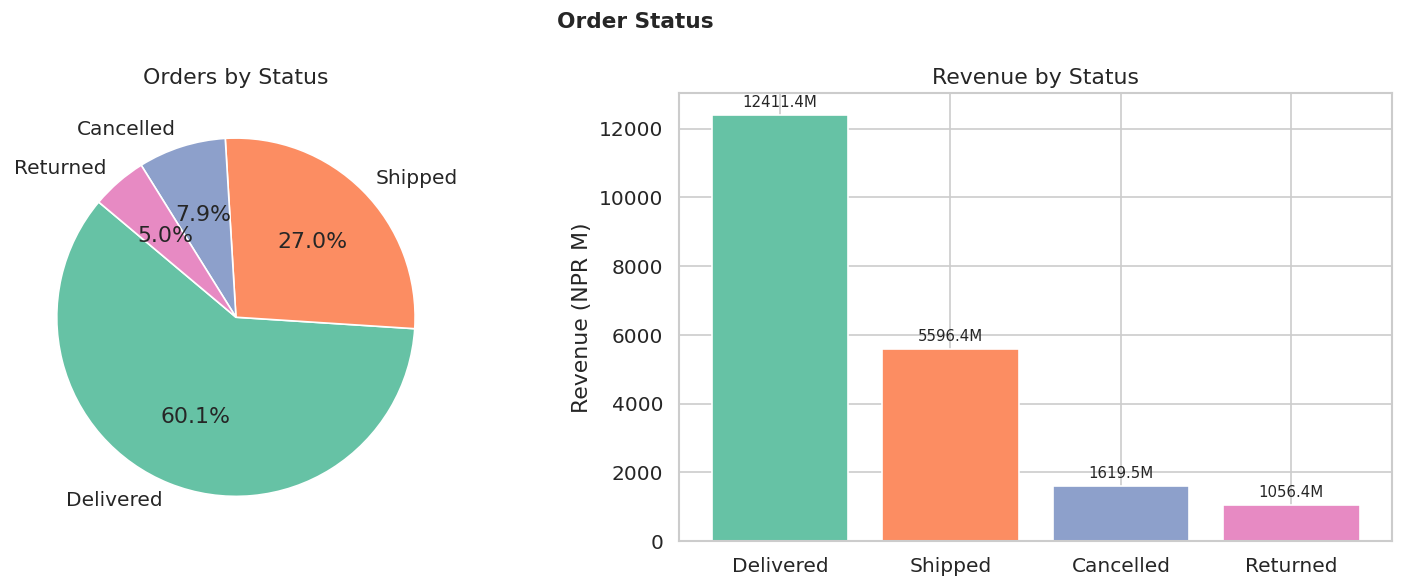

In [72]:
# order status breakdown — pie shows order share, bar shows revenue share
status_df = (
    fact
    .groupBy("order_status")
    .agg(
        F.countDistinct("order_id").alias("orders"),
        F.round(F.sum("revenue"), 2).alias("revenue"),
    )
    .orderBy(F.desc("revenue"))
    .toPandas()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Order Status", fontsize=13, fontweight="bold")

ax1.pie(status_df["orders"], labels=status_df["order_status"],
        autopct="%1.1f%%", startangle=140,
        colors=sns.color_palette("Set2", len(status_df)))
ax1.set_title("Orders by Status")

bars = ax2.bar(status_df["order_status"], status_df["revenue"] / 1e6,
               color=sns.color_palette("Set2", len(status_df)))
ax2.set_ylabel("Revenue (NPR M)")
ax2.set_title("Revenue by Status")
ax2.bar_label(bars, fmt="%.1fM", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Sales by Category

In [73]:
# aggregate revenue / profit / orders per category
cat_df = (
    delivered
    .groupBy("category")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.round(F.sum("profit"),  2).alias("profit"),
        F.countDistinct("order_id").alias("orders"),
        F.round(F.avg("discount_pct") * 100, 1).alias("avg_discount_pct"),
    )
    .orderBy(F.desc("revenue"))
    .toPandas()
)

cat_df

,category,revenue,profit,orders,avg_discount_pct
0,Electronics,7.690364e+09,2.033885e+09,47866,12.5
1,Home & Garden,2.064646e+09,5.456777e+08,28889,12.5
2,Sports & Outdoors,8.151213e+08,2.155647e+08,19161,12.4
3,Clothing,6.786879e+08,1.792437e+08,43391,12.5
4,Beauty & Health,4.234809e+08,1.119233e+08,31461,12.5
5,Toys & Games,3.033887e+08,8.020155e+07,22574,12.5
6,Food & Grocery,2.577986e+08,6.814435e+07,31152,12.5
7,Books,1.779244e+08,4.703397e+07,24056,12.5


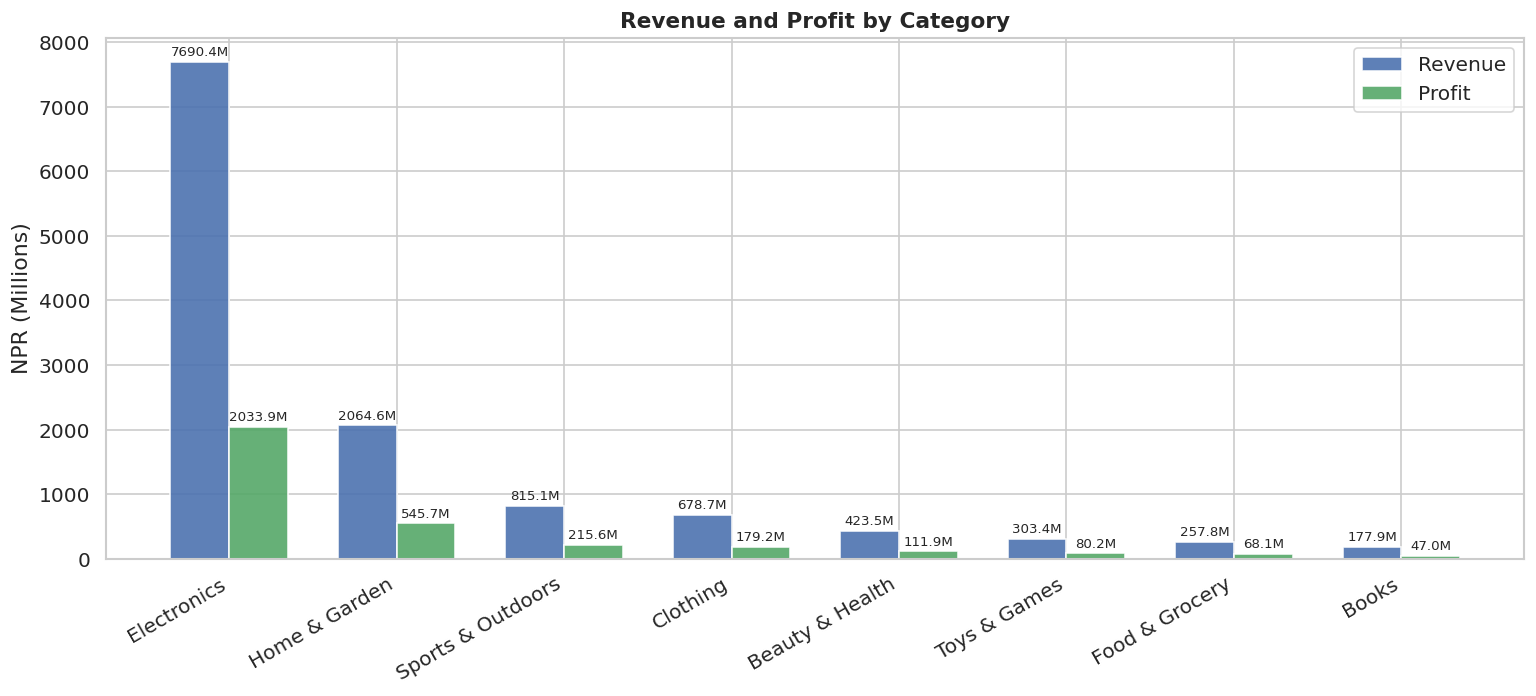

In [74]:
# grouped bar chart — revenue vs profit for each category side by side
x = np.arange(len(cat_df))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars_rev = ax.bar(x - width/2, cat_df["revenue"] / 1e6, width, label="Revenue", color="#4C72B0", alpha=0.9)
bars_pro = ax.bar(x + width/2, cat_df["profit"]  / 1e6, width, label="Profit",  color="#55A868", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cat_df["category"], rotation=30, ha="right")
ax.set_ylabel("NPR (Millions)")
ax.set_title("Revenue and Profit by Category", fontsize=13, fontweight="bold")
ax.legend()
ax.bar_label(bars_rev, fmt="%.1fM", padding=2, fontsize=8)
ax.bar_label(bars_pro, fmt="%.1fM", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

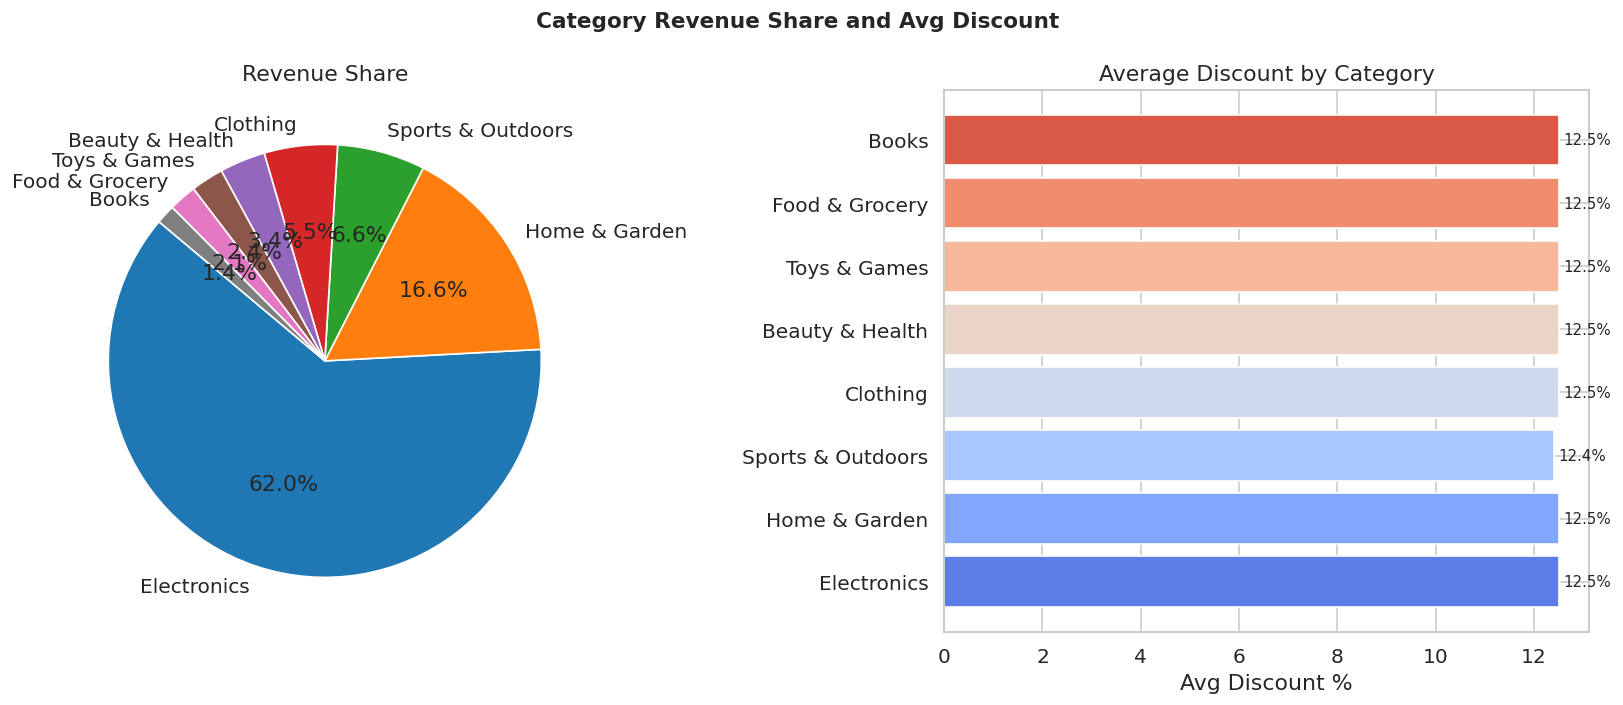

In [75]:
# left pie = revenue share, right bar = average discount per category
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Category Revenue Share and Avg Discount", fontsize=13, fontweight="bold")

ax1.pie(cat_df["revenue"], labels=cat_df["category"],
        autopct="%1.1f%%", startangle=140,
        colors=sns.color_palette("tab10", len(cat_df)))
ax1.set_title("Revenue Share")

bars = ax2.barh(cat_df["category"], cat_df["avg_discount_pct"],
                color=sns.color_palette("coolwarm", len(cat_df)))
ax2.set_xlabel("Avg Discount %")
ax2.set_title("Average Discount by Category")
ax2.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Sales by Region

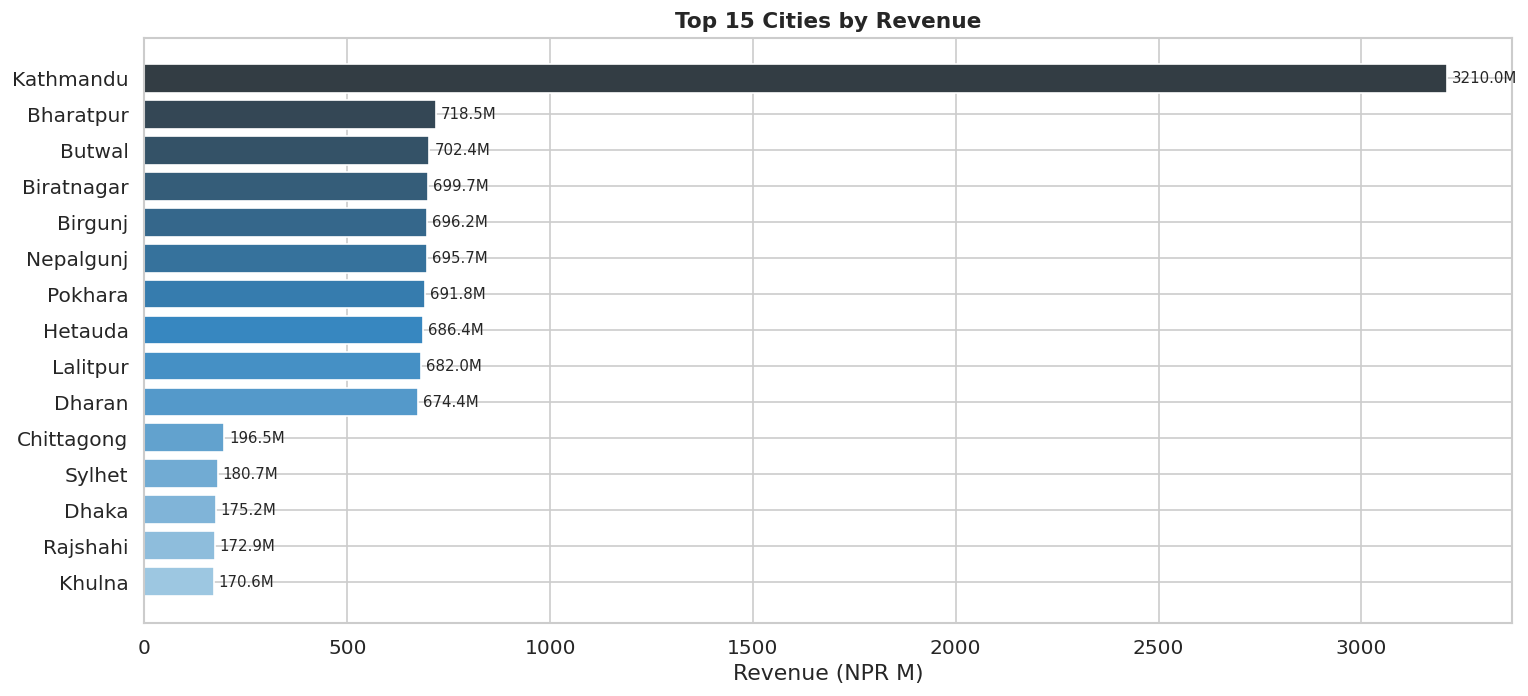

In [76]:
# top 15 cities by revenue — horizontal bar for easy label reading
city_df = (
    delivered
    .groupBy("shipping_city")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.round(F.sum("profit"),  2).alias("profit"),
        F.countDistinct("order_id").alias("orders"),
    )
    .orderBy(F.desc("revenue"))
    .limit(15)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(city_df["shipping_city"][::-1], city_df["revenue"][::-1] / 1e6,
               color=sns.color_palette("Blues_d", len(city_df)))
ax.set_xlabel("Revenue (NPR M)")
ax.set_title("Top 15 Cities by Revenue", fontsize=13, fontweight="bold")
ax.bar_label(bars, fmt="%.1fM", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Sales Over Time

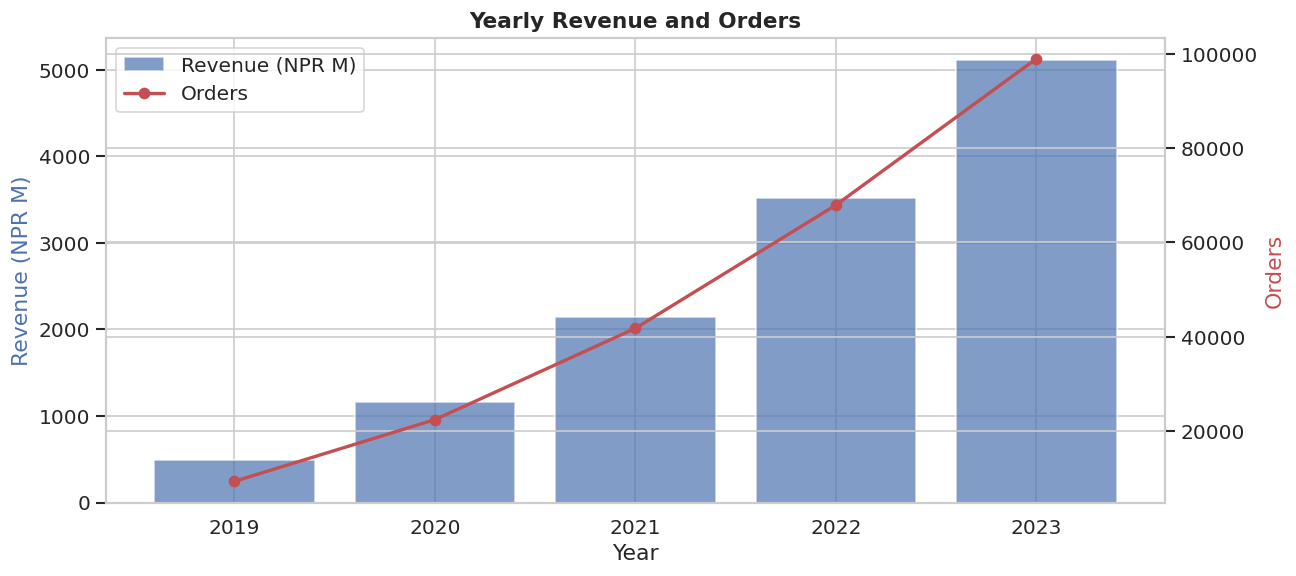

In [77]:
# yearly trend — bars for revenue, line for order count (dual axis)
year_df = (
    delivered
    .groupBy("order_year")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.countDistinct("order_id").alias("orders"),
    )
    .orderBy("order_year")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(year_df["order_year"], year_df["revenue"] / 1e6, color="#4C72B0", alpha=0.7, label="Revenue (NPR M)")
ax2.plot(year_df["order_year"], year_df["orders"], color="#C44E52", marker="o", linewidth=2, label="Orders")

ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue (NPR M)", color="#4C72B0")
ax2.set_ylabel("Orders",          color="#C44E52")
ax1.set_title("Yearly Revenue and Orders", fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

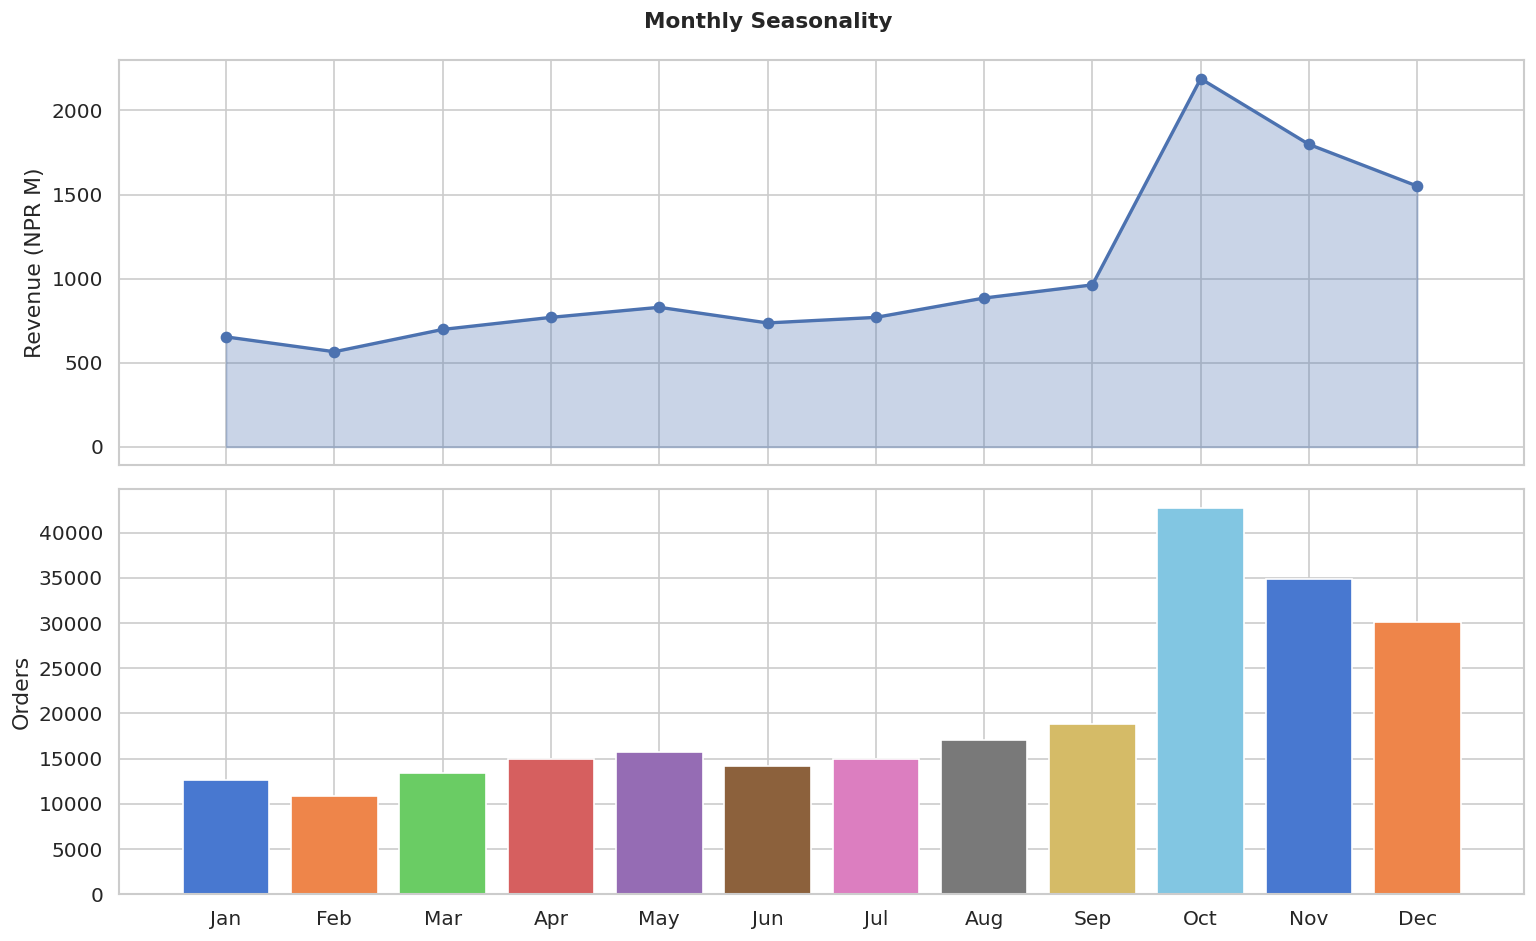

In [78]:
# monthly seasonality — area chart (revenue) and bar chart (orders)
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

month_df = (
    delivered
    .groupBy("order_month")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.countDistinct("order_id").alias("orders"),
    )
    .orderBy("order_month")
    .toPandas()
)
month_df["month_name"] = month_df["order_month"].apply(lambda m: MONTH_NAMES[m-1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("Monthly Seasonality", fontsize=13, fontweight="bold")

ax1.fill_between(month_df["month_name"], month_df["revenue"] / 1e6, alpha=0.3, color="#4C72B0")
ax1.plot(month_df["month_name"], month_df["revenue"] / 1e6, marker="o", color="#4C72B0", linewidth=2)
ax1.set_ylabel("Revenue (NPR M)")

ax2.bar(month_df["month_name"], month_df["orders"], color=sns.color_palette("muted", 12))
ax2.set_ylabel("Orders")

plt.tight_layout()
plt.show()

## Top and Low Performing Products

In [79]:
prod_df = (
    delivered
    .groupBy("product_id", "product_name", "category", "subcategory")
    .agg(
        F.round(F.sum("revenue"), 2).alias("revenue"),
        F.round(F.sum("profit"),  2).alias("profit"),
        F.sum("quantity").alias("units_sold"),
        F.countDistinct("order_id").alias("orders"),
    )
    .orderBy(F.desc("revenue"))
    .toPandas()
)

top10 = prod_df.head(10)
bot10 = prod_df.tail(10)

print(f"products with sales: {len(prod_df):,}")
top10[["product_name", "category", "revenue", "units_sold"]]

products with sales: 4,781


,product_name,category,revenue,units_sold
0,Phone Grip Stand Prime,Electronics,29042602.23,680
1,USB-C Hub Adapter Prime,Electronics,28968547.77,664
2,USB Flash Drive 64GB XL,Electronics,28200517.88,667
3,Laptop Cooling Pad Plus,Electronics,27359382.05,648
4,Phone Audio Adapter Ultra,Electronics,27097816.21,628
5,Portable Speaker Mini Lite,Electronics,26738346.44,616
6,Screen Protector HD 2023,Electronics,26615054.37,623
7,Laptop Stand Ergonomic Neo,Electronics,26431967.97,620
8,Microphone USB Studio Air,Electronics,26332731.30,623
9,Noise Cancelling Headset Pro,Electronics,26250789.68,597


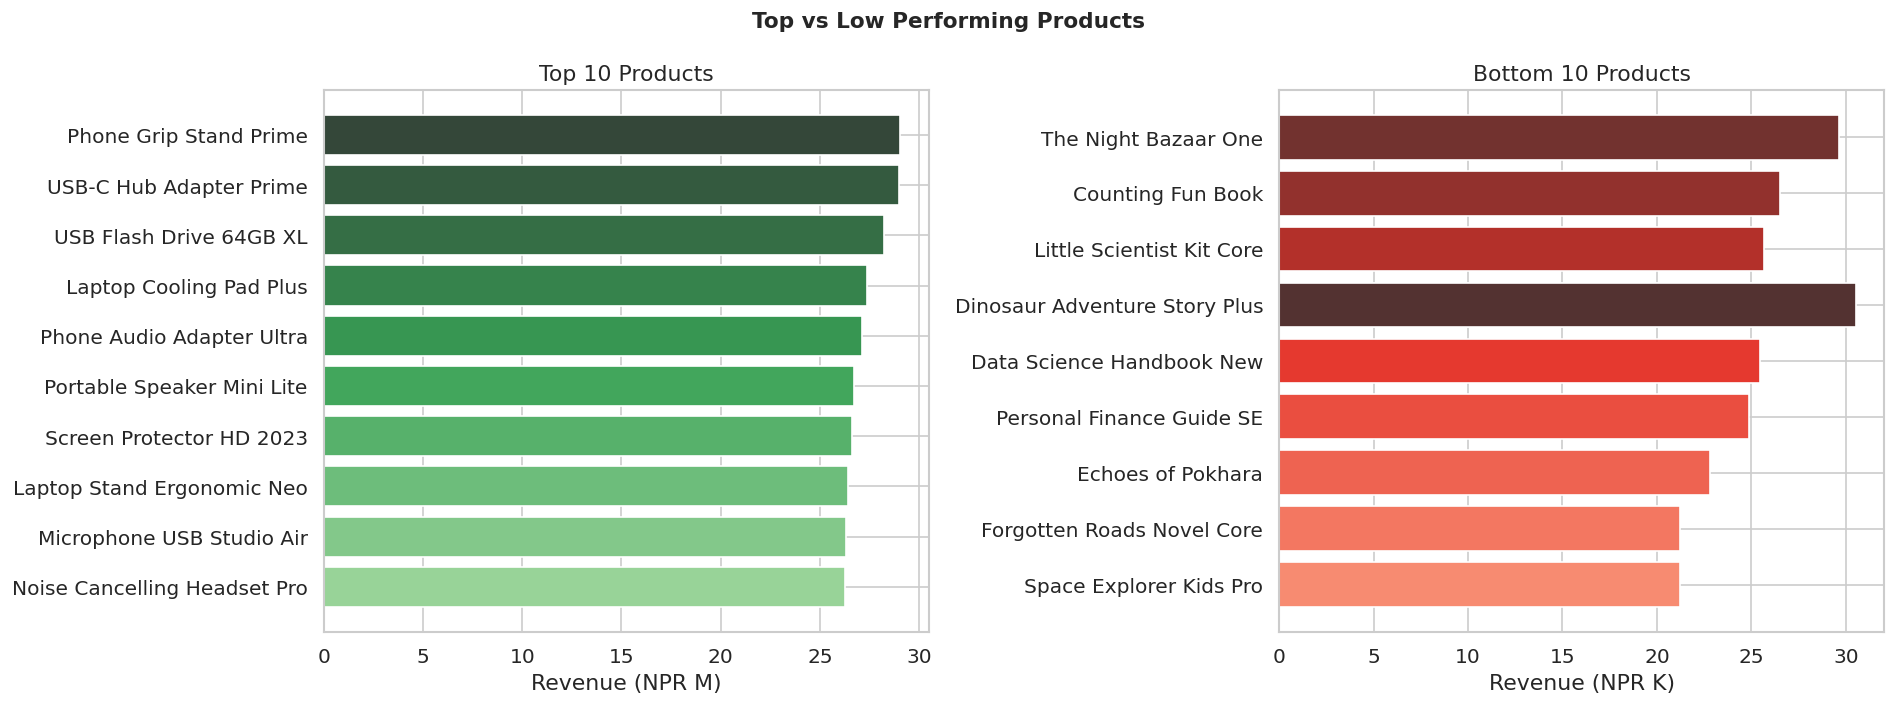

In [80]:
# side-by-side bars — top 10 vs bottom 10 products by revenue
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top vs Low Performing Products", fontsize=13, fontweight="bold")

top10_labels = [n[:30]+"..." if len(n) > 30 else n for n in top10["product_name"]]
bot10_labels = [n[:30]+"..." if len(n) > 30 else n for n in bot10["product_name"]]

ax1.barh(top10_labels[::-1], top10["revenue"][::-1] / 1e6,
         color=sns.color_palette("Greens_d", 10))
ax1.set_xlabel("Revenue (NPR M)")
ax1.set_title("Top 10 Products")

ax2.barh(bot10_labels[::-1], bot10["revenue"][::-1] / 1e3,
         color=sns.color_palette("Reds_d", 10))
ax2.set_xlabel("Revenue (NPR K)")
ax2.set_title("Bottom 10 Products")

plt.tight_layout()
plt.show()

---
## Revenue Forecasting (Time-Series Regression)

We aggregate **monthly revenue** from historical orders, then train PySpark MLlib
regression models to **forecast next month's revenue**.

**Approach:**
1. Roll up delivered revenue by year-month
2. Build lag features (last 1, 2, 3 months of revenue) so the model can learn trend
3. Train **Linear Regression**, **Decision Tree**, and **Random Forest** on the lagged series
4. Evaluate with RMSE, MAE, R² on a held-out test window
5. Plot actual vs predicted revenue to see model fit

In [ ]:
# ── Step 1: aggregate delivered revenue to monthly totals 
# we use year-month as the time index
monthly_rev = (
    delivered
    .withColumn("ym", F.date_format("order_date", "yyyy-MM"))
    .groupBy("ym")
    .agg(F.round(F.sum("revenue"), 2).alias("revenue"))
    .orderBy("ym")
    .toPandas()
)

monthly_rev["ym"] = pd.to_datetime(monthly_rev["ym"])
monthly_rev = monthly_rev.sort_values("ym").reset_index(drop=True)

print(f"{len(monthly_rev)} months of data  ({monthly_rev['ym'].min().date()} → {monthly_rev['ym'].max().date()})")
monthly_rev.head()

60 months of data  (2019-01-01 → 2023-12-01)


,ym,revenue
0,2019-01-01,13315689.06
1,2019-02-01,11608259.85
2,2019-03-01,16082923.79
3,2019-04-01,21534708.55
4,2019-05-01,28066448.37


In [ ]:
# ── Step 2: build lag features 
# lag_1 = revenue from 1 month ago, lag_2 = 2 months ago, lag_3 = 3 months ago
# the month index (t) gives the model a sense of trend over time
monthly_rev["t"]     = np.arange(len(monthly_rev))
monthly_rev["lag_1"] = monthly_rev["revenue"].shift(1)
monthly_rev["lag_2"] = monthly_rev["revenue"].shift(2)
monthly_rev["lag_3"] = monthly_rev["revenue"].shift(3)

# drop first 3 rows where lags are NaN
ts_df = monthly_rev.dropna().reset_index(drop=True)
print(f"rows after lag drop: {len(ts_df)}")
ts_df[["ym", "t", "lag_1", "lag_2", "lag_3", "revenue"]].head()

rows after lag drop: 57


,ym,t,lag_1,lag_2,lag_3,revenue
0,2019-04-01,3,16082923.79,11608259.85,13315689.06,21534708.55
1,2019-05-01,4,21534708.55,16082923.79,11608259.85,28066448.37
2,2019-06-01,5,28066448.37,21534708.55,16082923.79,28622060.82
3,2019-07-01,6,28622060.82,28066448.37,21534708.55,29448018.69
4,2019-08-01,7,29448018.69,28622060.82,28066448.37,36861290.72


In [ ]:
# ── Step 3: convert to Spark for MLlib 
# Spark expects a label column and a features vector
ts_spark = spark.createDataFrame(ts_df[["t", "lag_1", "lag_2", "lag_3", "revenue"]])

ts_assembler = VectorAssembler(
    inputCols=["t", "lag_1", "lag_2", "lag_3"],
    outputCol="features"
)
ts_spark = ts_assembler.transform(ts_spark).withColumnRenamed("revenue", "label")

# 80 / 20 chronological split — DO NOT shuffle time-series data
split_idx = int(len(ts_df) * 0.8)
train_ts = ts_spark.filter(F.col("t") < split_idx)
test_ts  = ts_spark.filter(F.col("t") >= split_idx)

print(f"train months: {train_ts.count()}  |  test months: {test_ts.count()}")

train months: 42  |  test months: 15


In [ ]:
# ── Step 4: train three models and evaluate 
from pyspark.ml.regression import DecisionTreeRegressor

def eval_ts(model, name, train, test):
    fitted = model.fit(train)
    preds  = fitted.transform(test)

    rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse").evaluate(preds)
    mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae" ).evaluate(preds)
    r2   = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2"  ).evaluate(preds)

    print(f"{name:22s}  RMSE={rmse/1e6:7.2f}M  MAE={mae/1e6:6.2f}M  R²={r2:.3f}")
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2, "fitted": fitted}

lr = LinearRegression(featuresCol="features", labelCol="label")
dt = DecisionTreeRegressor(featuresCol="features", labelCol="label", maxDepth=5)
rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=50, maxDepth=5, seed=42)

ts_results = []
ts_results.append(eval_ts(lr, "Linear Regression", train_ts, test_ts))
ts_results.append(eval_ts(dt, "Decision Tree",     train_ts, test_ts))
ts_results.append(eval_ts(rf, "Random Forest",     train_ts, test_ts))

Linear Regression       RMSE= 168.90M  MAE= 96.13M  R²=0.150
Decision Tree           RMSE= 305.16M  MAE=245.29M  R²=-1.775


Random Forest           RMSE= 275.69M  MAE=208.05M  R²=-1.265


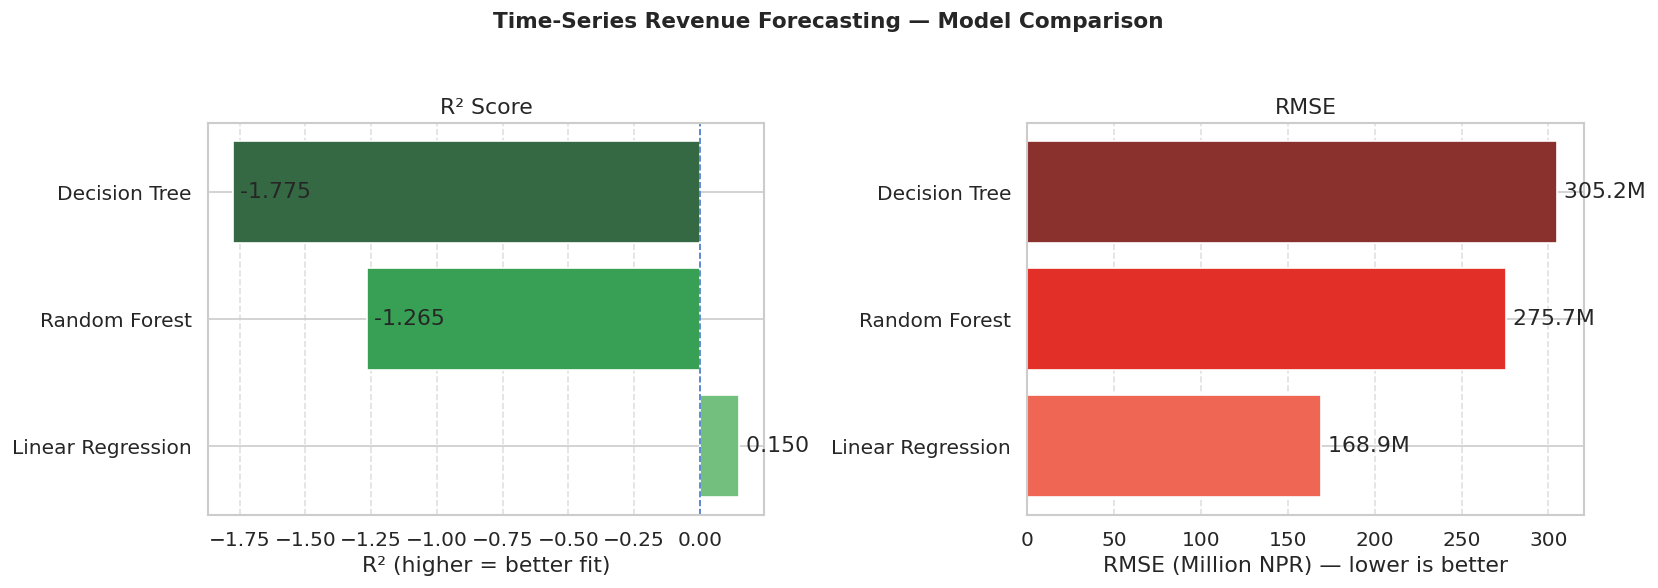

,model,rmse,mae,r2,rmse_m
0,Linear Regression,1.689037e+08,9.613018e+07,0.149718,168.903693
2,Random Forest,2.756878e+08,2.080540e+08,-1.265271,275.687840
1,Decision Tree,3.051566e+08,2.452947e+08,-1.775431,305.156589


In [101]:
import seaborn as sns

# Prepare data
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != "fitted"} for r in ts_results])
res_df = res_df.sort_values("r2", ascending=False)

# Convert RMSE to millions
res_df["rmse_m"] = res_df["rmse"] / 1e6

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Time-Series Revenue Forecasting — Model Comparison", fontsize=13, fontweight="bold")

# ── R² (horizontal + baseline) ─────────────────────────────
colors_r2 = sns.color_palette("Greens_d", len(res_df))

b1 = ax1.barh(res_df["model"], res_df["r2"], color=colors_r2)
ax1.set_xlabel("R² (higher = better fit)")
ax1.set_title("R² Score")

# Key improvement: baseline at 0
ax1.axvline(0, linestyle="--", linewidth=1)

# Grid for readability
ax1.grid(axis="x", linestyle="--", alpha=0.6)

# Labels
for i, v in enumerate(res_df["r2"]):
    ax1.text(v, i, f" {v:.3f}", va="center")

# ── RMSE (horizontal) ─────────────────────────────────────
colors_rmse = sns.color_palette("Reds_d", len(res_df))

b2 = ax2.barh(res_df["model"], res_df["rmse_m"], color=colors_rmse)
ax2.set_xlabel("RMSE (Million NPR) — lower is better")
ax2.set_title("RMSE")

ax2.grid(axis="x", linestyle="--", alpha=0.6)

# Labels
for i, v in enumerate(res_df["rmse_m"]):
    ax2.text(v, i, f" {v:.1f}M", va="center")

# Layout fix for title
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("forecasting_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

res_df

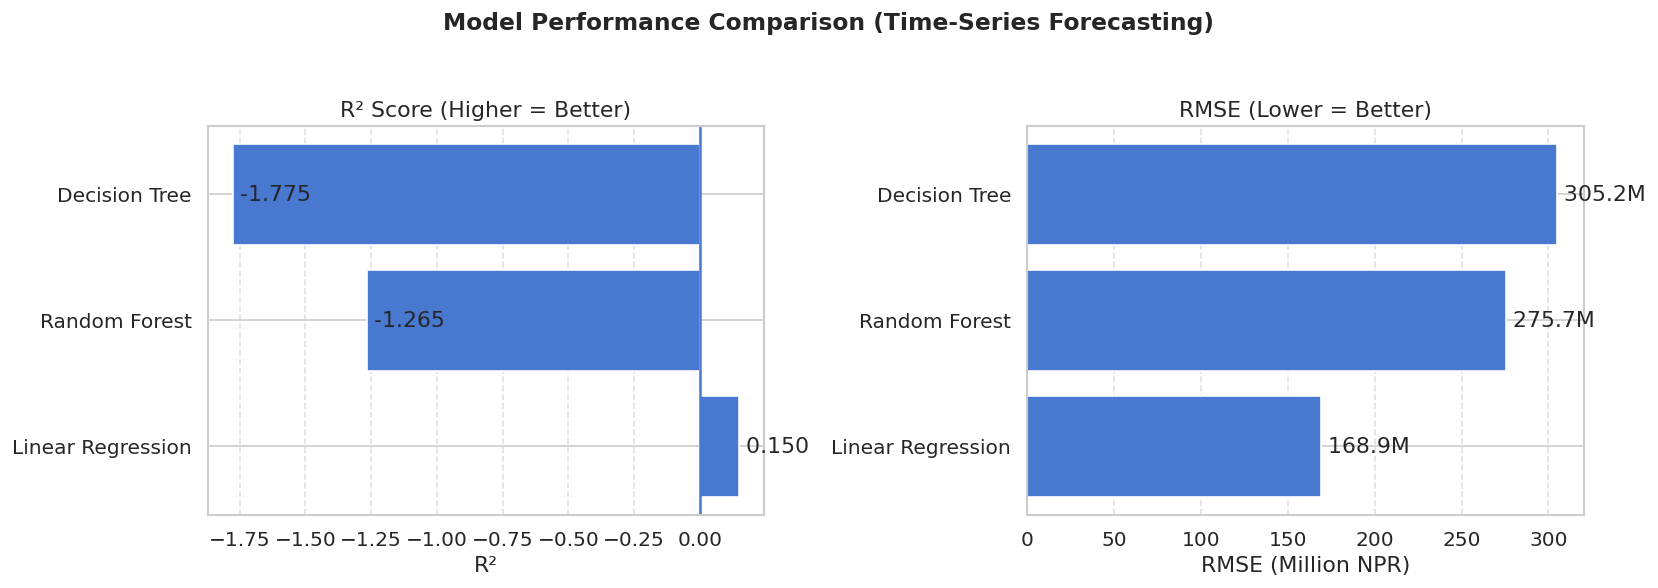

,model,rmse,mae,r2,rmse_m
0,Linear Regression,1.689037e+08,9.613018e+07,0.149718,168.903693
2,Random Forest,2.756878e+08,2.080540e+08,-1.265271,275.687840
1,Decision Tree,3.051566e+08,2.452947e+08,-1.775431,305.156589


In [ ]:
# Prepare data
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != "fitted"} for r in ts_results])

# Sort by performance
res_df = res_df.sort_values("r2", ascending=False)

# Convert RMSE to millions
res_df["rmse_m"] = res_df["rmse"] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Performance Comparison (Time-Series Forecasting)", fontsize=14, fontweight="bold")

#  R² Plot 
ax = axes[0]
bars = ax.barh(res_df["model"], res_df["r2"])

ax.set_title("R² Score (Higher = Better)")
ax.set_xlabel("R²")
ax.axvline(0)  # important baseline
ax.grid(axis="x", linestyle="--", alpha=0.6)

# Labels
for i, v in enumerate(res_df["r2"]):
    ax.text(v, i, f" {v:.3f}", va="center")

#  RMSE Plot 
ax = axes[1]
bars = ax.barh(res_df["model"], res_df["rmse_m"])

ax.set_title("RMSE (Lower = Better)")
ax.set_xlabel("RMSE (Million NPR)")
ax.grid(axis="x", linestyle="--", alpha=0.6)

# Labels
for i, v in enumerate(res_df["rmse_m"]):
    ax.text(v, i, f" {v:.1f}M", va="center")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("better_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

res_df

---
## Customer Segmentation (K-Means Clustering)

Group customers into segments using Recency, Frequency, Monetary features.
We try several **K** values and pick the best one using the **elbow method** + **silhouette score**.

In [87]:
# import clustering libs
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# build RFM features per customer
# recency = days since last order, frequency = number of orders, monetary = total revenue
max_date = delivered.agg(F.max("order_date")).collect()[0][0]

rfm = (
    delivered
    .groupBy("customer_id")
    .agg(
        F.datediff(F.lit(max_date), F.max("order_date")).alias("recency"),
        F.countDistinct("order_id").alias("frequency"),
        F.sum("revenue").alias("monetary"),
    )
    .filter(F.col("monetary") > 0)
)

print(f"customers with rfm: {rfm.count():,}")
rfm.show(5)

customers with rfm: 96,949


+-----------+-------+---------+------------------+
|customer_id|recency|frequency|          monetary|
+-----------+-------+---------+------------------+
|cust_036598|     65|        4|          26828.49|
|cust_021078|    400|        5|343774.97000000003|
|cust_116168|    442|        4|348623.41000000003|
|cust_086162|    308|        4|46036.880000000005|
|cust_035248|    191|        5|         212431.57|
+-----------+-------+---------+------------------+
only showing top 5 rows


In [88]:
# assemble + scale RFM features
rfm_assembler = VectorAssembler(
    inputCols=["recency", "frequency", "monetary"],
    outputCol="rfm_raw"
)
rfm_scaler = StandardScaler(inputCol="rfm_raw", outputCol="features", withMean=True, withStd=True)

rfm_prep = Pipeline(stages=[rfm_assembler, rfm_scaler]).fit(rfm).transform(rfm).cache()
print(f"rfm feature rows: {rfm_prep.count():,}")

rfm feature rows: 96,949


In [89]:
# try K = 2..7 and record inertia (WSSSE) and silhouette score
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette")

k_results = []
for k in range(2, 8):
    km = KMeans(featuresCol="features", k=k, seed=42)
    model_k = km.fit(rfm_prep)
    preds_k = model_k.transform(rfm_prep)
    wssse = model_k.summary.trainingCost
    sil = evaluator.evaluate(preds_k)
    k_results.append({"k": k, "wssse": wssse, "silhouette": sil})
    print(f"k={k}  WSSSE={wssse:10.1f}  silhouette={sil:.3f}")

k_df = pd.DataFrame(k_results)

k=2  WSSSE=  179661.4  silhouette=0.592
k=3  WSSSE=  119927.1  silhouette=0.569
k=4  WSSSE=   97071.2  silhouette=0.511
k=5  WSSSE=   85744.1  silhouette=0.443
k=6  WSSSE=   72051.6  silhouette=0.511
k=7  WSSSE=   61326.5  silhouette=0.487


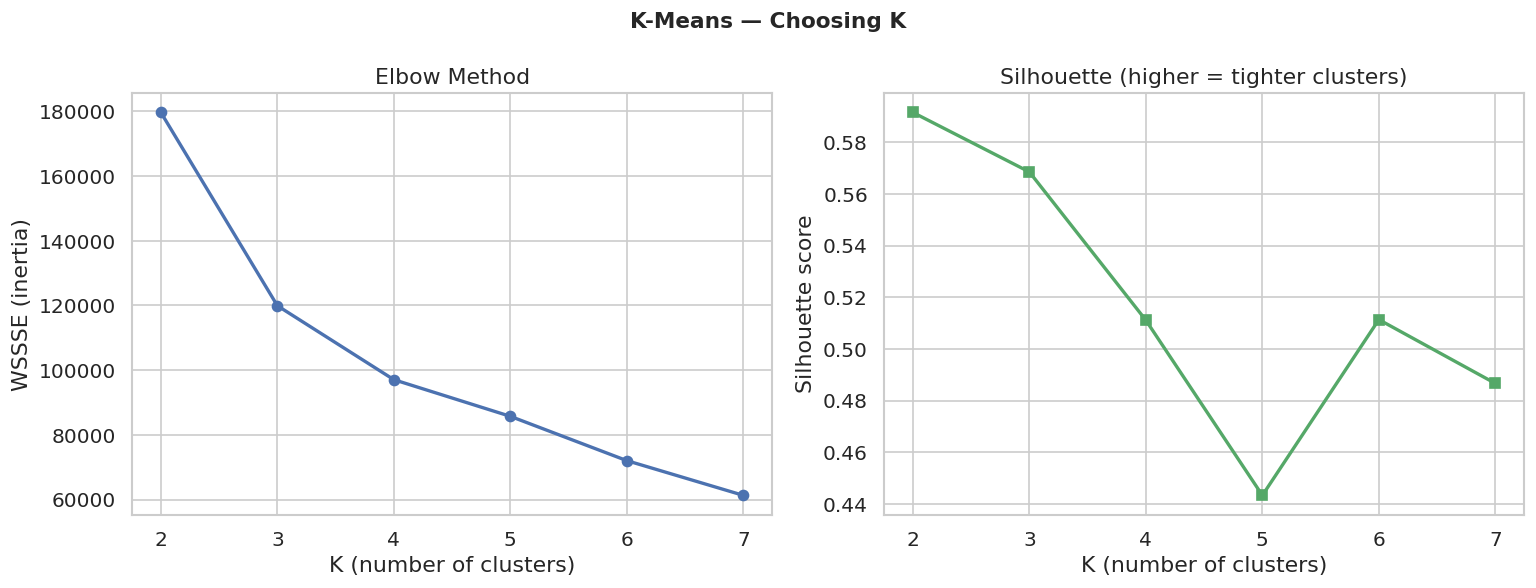

best k by silhouette: 2


In [90]:
# elbow + silhouette plot — pick the best K
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("K-Means — Choosing K", fontsize=13, fontweight="bold")

# elbow: look for the bend
ax1.plot(k_df["k"], k_df["wssse"], marker="o", color="#4C72B0", linewidth=2)
ax1.set_xlabel("K (number of clusters)")
ax1.set_ylabel("WSSSE (inertia)")
ax1.set_title("Elbow Method")

# silhouette: higher is better
ax2.plot(k_df["k"], k_df["silhouette"], marker="s", color="#55A868", linewidth=2)
ax2.set_xlabel("K (number of clusters)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette (higher = tighter clusters)")

plt.tight_layout()
plt.savefig("cluster_elbow_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()

# best k = highest silhouette
best_k = int(k_df.loc[k_df["silhouette"].idxmax(), "k"])
print(f"best k by silhouette: {best_k}")

In [91]:
# fit final K-Means with the best K
km_final = KMeans(featuresCol="features", k=best_k, seed=42)
km_model = km_final.fit(rfm_prep)
clustered = km_model.transform(rfm_prep)

# profile each cluster — mean RFM per cluster + customer count
profile = (
    clustered
    .groupBy("prediction")
    .agg(
        F.round(F.avg("recency"),    1).alias("avg_recency_days"),
        F.round(F.avg("frequency"),  2).alias("avg_frequency"),
        F.round(F.avg("monetary"),   2).alias("avg_monetary"),
        F.count("*").alias("customers"),
    )
    .orderBy("prediction")
    .toPandas()
)

profile

,prediction,avg_recency_days,avg_frequency,avg_monetary,customers
0,0,431.8,1.73,66561.26,71593
1,1,160.1,4.61,301549.57,25356


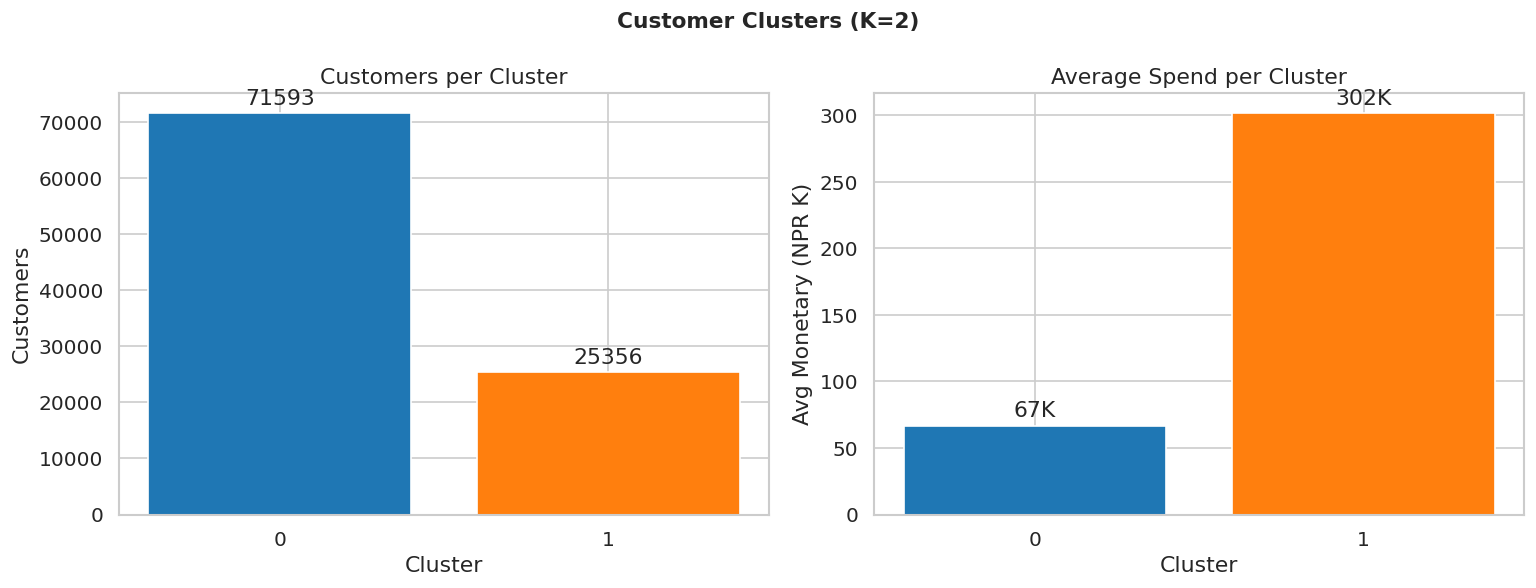

In [92]:
# visualise cluster sizes and average monetary value
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Customer Clusters (K={best_k})", fontsize=13, fontweight="bold")

b1 = ax1.bar(profile["prediction"].astype(str), profile["customers"],
             color=sns.color_palette("tab10", len(profile)))
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Customers")
ax1.set_title("Customers per Cluster")
ax1.bar_label(b1, fmt="%d", padding=3)

b2 = ax2.bar(profile["prediction"].astype(str), profile["avg_monetary"] / 1e3,
             color=sns.color_palette("tab10", len(profile)))
ax2.set_xlabel("Cluster")
ax2.set_ylabel("Avg Monetary (NPR K)")
ax2.set_title("Average Spend per Cluster")
ax2.bar_label(b2, fmt="%.0fK", padding=3)

plt.tight_layout()
plt.savefig("cluster_customers_per_cluster.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Market Basket Analysis (FP-Growth)

Find products frequently bought **together** in the same order.
We use PySpark MLlib's **FP-Growth** algorithm to mine association rules.

**Metrics:**
- **Support** : how often the itemset appears
- **Confidence** : P(consequent | antecedent)
- **Lift** : how much more likely the pair is vs. random (lift > 1 means positively associated)

In [93]:
# import FP-Growth
from pyspark.ml.fpm import FPGrowth

# build baskets: one row per order, with a list of product categories in that order
# using category keeps the rule count manageable and interpretable
baskets = (
    delivered
    .groupBy("order_id")
    .agg(F.collect_set("category").alias("items"))
    .filter(F.size("items") >= 2)   # only multi-item baskets
)

print(f"multi-item baskets: {baskets.count():,}")
baskets.show(5, truncate=False)

multi-item baskets: 8,198


+----------+------------------------------------+
|order_id  |items                               |
+----------+------------------------------------+
|ord_000169|[Beauty & Health, Sports & Outdoors]|
|ord_000433|[Toys & Games, Books]               |
|ord_000509|[Beauty & Health, Sports & Outdoors]|
|ord_000806|[Beauty & Health, Sports & Outdoors]|
|ord_000844|[Toys & Games, Books]               |
+----------+------------------------------------+
only showing top 5 rows


In [94]:
# fit FP-Growth
# minSupport = 0.01  → itemset must appear in ≥1% of baskets
# minConfidence = 0.3 → keep rules with ≥30% confidence
fp = FPGrowth(itemsCol="items", minSupport=0.01, minConfidence=0.3)
fp_model = fp.fit(baskets)

# frequent itemsets
freq_items = fp_model.freqItemsets.orderBy(F.desc("freq")).toPandas()
print(f"frequent itemsets: {len(freq_items)}")
freq_items.head(15)

frequent itemsets: 8


,items,freq
0,[Toys & Games],5304
1,[Books],3206
2,"[Books, Toys & Games]",3206
3,[Sports & Outdoors],2894
4,[Beauty & Health],2894
5,"[Beauty & Health, Sports & Outdoors]",2894
6,[Food & Grocery],2098
7,"[Food & Grocery, Toys & Games]",2098


In [95]:
# association rules — antecedent -> consequent with confidence and lift
rules = (
    fp_model.associationRules
    .orderBy(F.desc("lift"))
    .toPandas()
)

# format items lists as strings for display
rules["antecedent"] = rules["antecedent"].apply(lambda x: ", ".join(x))
rules["consequent"] = rules["consequent"].apply(lambda x: ", ".join(x))

print(f"rules mined: {len(rules)}")
rules.head(15)

rules mined: 6


,antecedent,consequent,confidence,lift,support
0,Beauty & Health,Sports & Outdoors,1.000000,2.832757,0.353013
1,Sports & Outdoors,Beauty & Health,1.000000,2.832757,0.353013
2,Food & Grocery,Toys & Games,1.000000,1.545626,0.255916
3,Books,Toys & Games,1.000000,1.545626,0.391071
4,Toys & Games,Books,0.604449,1.545626,0.391071
5,Toys & Games,Food & Grocery,0.395551,1.545626,0.255916


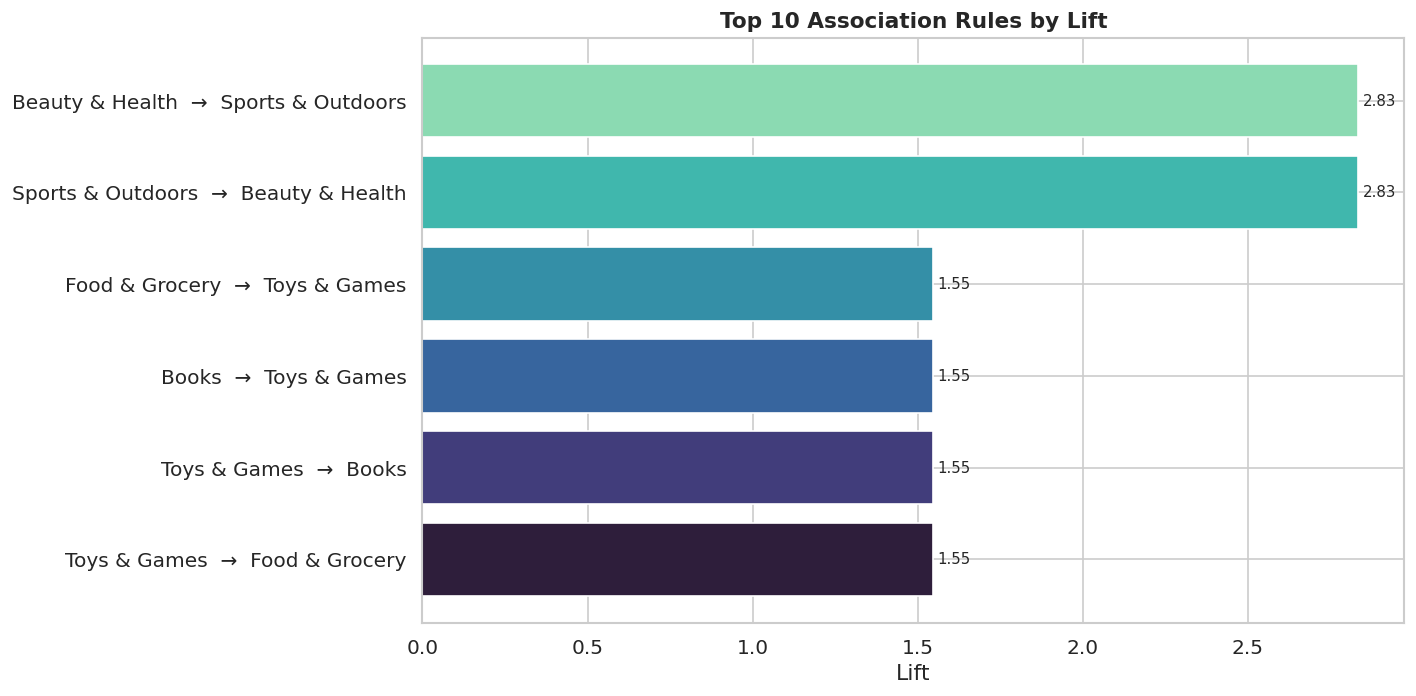

In [97]:
# top 10 rules by lift — the strongest cross-sell opportunities
if len(rules) > 0:
    top_rules = rules.head(10).copy()
    top_rules["rule"] = top_rules["antecedent"] + "  →  " + top_rules["consequent"]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(top_rules["rule"][::-1], top_rules["lift"][::-1],
                   color=sns.color_palette("mako", len(top_rules)))
    ax.set_xlabel("Lift")
    ax.set_title("Top 10 Association Rules by Lift", fontsize=13, fontweight="bold")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    plt.tight_layout()
    plt.savefig("market_basket_top_rules.png", dpi=120, bbox_inches="tight")
    plt.show()

    top_rules[["antecedent", "consequent", "support", "confidence", "lift"]]

**Market-basket business use case**

- Rules with **lift > 1** mean the two categories are bought together more often than by chance — strong signal for **cross-selling**.
- Place high-lift pairs near each other on the homepage and in the "Frequently bought together" widget.
- Run **bundle discounts** for the top-lift pairs. e.g. discount category B when the cart already contains category A.
- High-confidence rules tell us *which* recommendation to show once a customer has picked the antecedent item.

In [98]:
# ── Stop Spark when done ──────────────────────────────────────────────────────
spark.stop()
print("Spark session stopped.")


Spark session stopped.
